# Notebook 08 —Inferential Statistics Notebook

Tests the statistical significance of model-enumerator agreement using five complementary tests.

**Tests performed:**
1. **Wilcoxon Signed-Rank** — Is the median FCover difference significantly ≠ 0?
2. **Spearman Rank Correlation** — Is there a significant monotonic relationship between predicted and enumerator FCover?
3. **McNemar Test** — Does binary cropland classification agree between UAV and enumerator?
4. **Kruskal-Wallis + Dunn post-hoc** — Does cultivation intensity differ significantly across farming systems?
5. **OLS Regression** — Is the slope significantly ≠ 1 and intercept significantly ≠ 0?

## Cell 0. Configuration

In [3]:
pip install scikit-posthocs statsmodels

Note: you may need to restart the kernel to use updated packages.


In [1]:
# ── Configuration ────────────────────────────────────────────────────────
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import (wilcoxon, spearmanr, kruskal,
                          pearsonr, chi2_contingency)
from statsmodels.stats.contingency_tables import mcnemar
import statsmodels.api as sm
from scikit_posthocs import posthoc_dunn   # pip install scikit-posthocs
import warnings
warnings.filterwarnings("ignore")

BASE_DIR  = Path(r"E:\THESIS_COLLINS HLORDZIE\02_PROCESSED")
STATS_DIR = BASE_DIR / "AgriStats"
FIG_DIR   = STATS_DIR / "Figures" / "InferentialStats"
FIG_DIR.mkdir(parents=True, exist_ok=True)

ENUM_DIR  = BASE_DIR / "Enumerator_Data"

# ── Style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "axes.labelsize":    11,
    "xtick.labelsize":   9.5,
    "ytick.labelsize":   9.5,
})
ALPHA = 0.05
print("Config ready.")
print(f"Figures -> {FIG_DIR}")
print(f"Significance level: α = {ALPHA}")

Config ready.
Figures -> E:\THESIS_COLLINS HLORDZIE\02_PROCESSED\AgriStats\Figures\InferentialStats
Significance level: α = 0.05


## Cell 1. Load data

In [7]:
# ── Load data ─────────────────────────────────────────────────────────────
fcover_df  = pd.read_csv(BASE_DIR / "segment_fcover_results.csv")

# Auto-detect engine based on file extension
_enum_path = next(f for f in ENUM_DIR.glob("Enumerator_Data.*")
                  if f.suffix.lower() in (".xls", ".xlsx"))
_engine    = "openpyxl" if _enum_path.suffix.lower() == ".xlsx" else "xlrd"
enum_df    = pd.read_excel(_enum_path, engine=_engine)

enum_df["newgid"]     = enum_df["newgid"].astype(str).str.strip()
enum_df["crop_cov_1"] = pd.to_numeric(enum_df["crop_cov_1"], errors="coerce")
fcover_df["newgid"]   = fcover_df["newgid"].astype(str).str.strip()

# Sum all crop classes (exclude Grass) for total predicted crop cover
crop_cols = [c for c in fcover_df.columns
             if c.startswith("pred_fcover_") and "Grass" not in c]
fcover_df["pred_total_crop"] = fcover_df[crop_cols].sum(axis=1)

# crop_cov_1 already in fcover_df — only merge landform_e from enum_df
merged = fcover_df.merge(
    enum_df[["newgid","landform_e"]], on="newgid", how="left")
merged = merged.dropna(subset=["crop_cov_1"])

rgb = merged[merged["modality"].str.contains("rgb")].copy()
ms  = merged[merged["modality"].str.contains("ms") &
             ~merged["modality"].str.contains("unmask")].copy()

print(f"RGB segments : {len(rgb)}")
print(f"MS  segments : {len(ms)}")
print(f"Enumerator crop_cov_1 mean : {rgb['crop_cov_1'].mean():.2f}%")
print(f"RGB pred mean             : {rgb['pred_total_crop'].mean():.2f}%")
print(f"MS  pred mean             : {ms['pred_total_crop'].mean():.2f}%")

# Also load farming system data
farming_df = pd.read_csv(STATS_DIR / "farming_system_classification.csv")
area_df    = pd.read_csv(STATS_DIR / "crop_area_per_sa.csv")

RGB segments : 238
MS  segments : 238
Enumerator crop_cov_1 mean : 26.38%
RGB pred mean             : 89.64%
MS  pred mean             : 85.39%


## Test 1. Wilcoxon Signed-Rank Test

Non-parametric test for paired differences. More appropriate than paired t-test as FCover values are not normally distributed.

TEST 1: WILCOXON SIGNED-RANK TEST
H₀: Median difference between predicted and enumerator FCover = 0

  RGB
  Wilcoxon statistic : 1186.5000
  p-value            : 0.000000
  Median difference  : 94.86%
  Decision           : REJECT H₀
  Interpretation     : The predicted RGB crop cover is significantly different from enumerator estimates (α=0.05)

  MS
  Wilcoxon statistic : 848.5000
  p-value            : 0.000000
  Median difference  : 88.90%
  Decision           : REJECT H₀
  Interpretation     : The predicted MS crop cover is significantly different from enumerator estimates (α=0.05)

Saved -> fig_w1_wilcoxon_differences.png


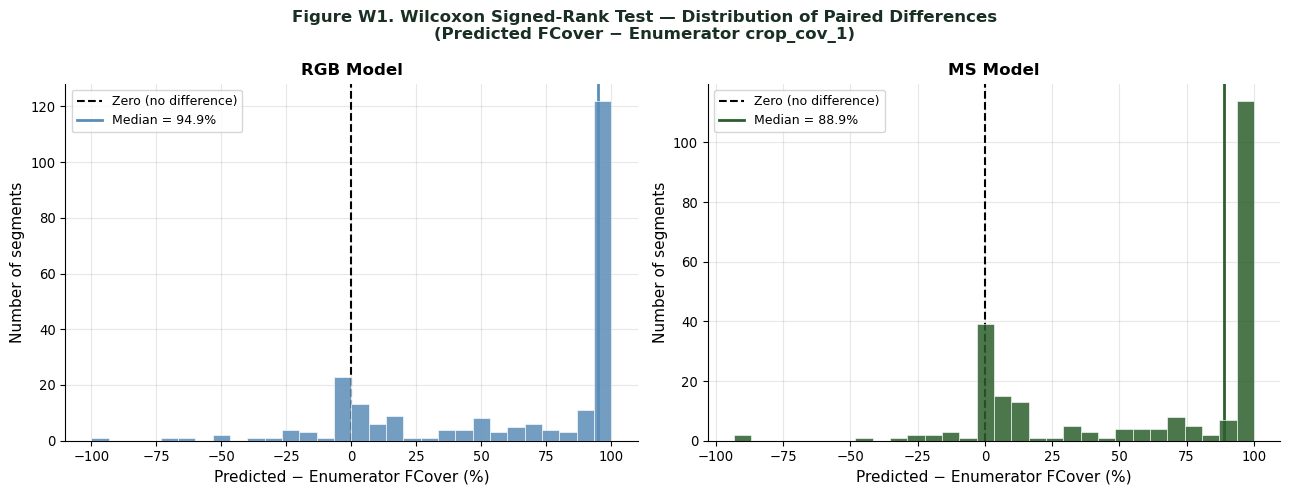

In [8]:
# ══════════════════════════════════════════════════════════════════
# TEST 1 — WILCOXON SIGNED-RANK TEST
# H₀: No significant difference between predicted and enumerator FCover
# ══════════════════════════════════════════════════════════════════
print("="*65)
print("TEST 1: WILCOXON SIGNED-RANK TEST")
print("H₀: Median difference between predicted and enumerator FCover = 0")
print("="*65)

results_wilcox = []
for label, df in [("RGB", rgb), ("MS", ms)]:
    pred = df["pred_total_crop"].values
    enum = df["crop_cov_1"].values
    diff = pred - enum

    stat, p = wilcoxon(pred, enum, alternative="two-sided")
    median_diff = np.median(diff)
    reject = p < ALPHA

    print(f"\n  {label}")
    print(f"  Wilcoxon statistic : {stat:.4f}")
    print(f"  p-value            : {p:.6f}")
    print(f"  Median difference  : {median_diff:.2f}%")
    print(f"  Decision           : {'REJECT H₀' if reject else 'FAIL TO REJECT H₀'}")
    print(f"  Interpretation     : The predicted {label} crop cover is "
          f"{'significantly different' if reject else 'not significantly different'} "
          f"from enumerator estimates (α={ALPHA})")
    results_wilcox.append({"Model":label,"Statistic":round(stat,4),
        "p-value":round(p,6),"Median diff (%)":round(median_diff,2),
        "Reject H0":reject})

wilcox_df = pd.DataFrame(results_wilcox)

# ── Figure: paired differences distribution ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor="white")
fig.suptitle(
    "Figure W1. Wilcoxon Signed-Rank Test — Distribution of Paired Differences\n"
    "(Predicted FCover − Enumerator crop_cov_1)",
    fontsize=12, fontweight="bold", color="#1A2F23")

for ax, (label, df, color) in zip(axes, [
    ("RGB", rgb, "#5B8DB8"), ("MS", ms, "#2C5F2D")
]):
    diff = df["pred_total_crop"].values - df["crop_cov_1"].values
    ax.hist(diff, bins=30, color=color, edgecolor="white",
            linewidth=0.5, alpha=0.85, zorder=3)
    ax.axvline(0, color="black", lw=1.5, linestyle="--",
               label="Zero (no difference)")
    ax.axvline(np.median(diff), color=color, lw=2.0,
               linestyle="-", label=f"Median = {np.median(diff):.1f}%")
    ax.set_xlabel("Predicted − Enumerator FCover (%)")
    ax.set_ylabel("Number of segments")
    ax.set_title(f"{label} Model", fontweight="bold")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR/"fig_w1_wilcoxon_differences.png",
            dpi=150, bbox_inches="tight")
print(f"\nSaved -> fig_w1_wilcoxon_differences.png")
plt.show()

## Test 2. Spearman Rank Correlation

Tests monotonic association. Reported alongside Pearson r for comparison — if Spearman ρ > Pearson r, the relationship is monotonic but non-linear.

TEST 2: SPEARMAN RANK CORRELATION
H₀: No monotonic association between predicted and enumerator FCover

  RGB
  Spearman ρ         : -0.0792
  p-value            : 0.223368
  Pearson r          : 0.0209
  Decision           : FAIL TO REJECT H₀
  Interpretation     : There is no significant monotonic association (ρ=-0.079, p=0.2234)

  MS
  Spearman ρ         : 0.0672
  p-value            : 0.302079
  Pearson r          : 0.1430
  Decision           : FAIL TO REJECT H₀
  Interpretation     : There is no significant monotonic association (ρ=0.067, p=0.3021)
Saved -> fig_s1_spearman_scatter.png


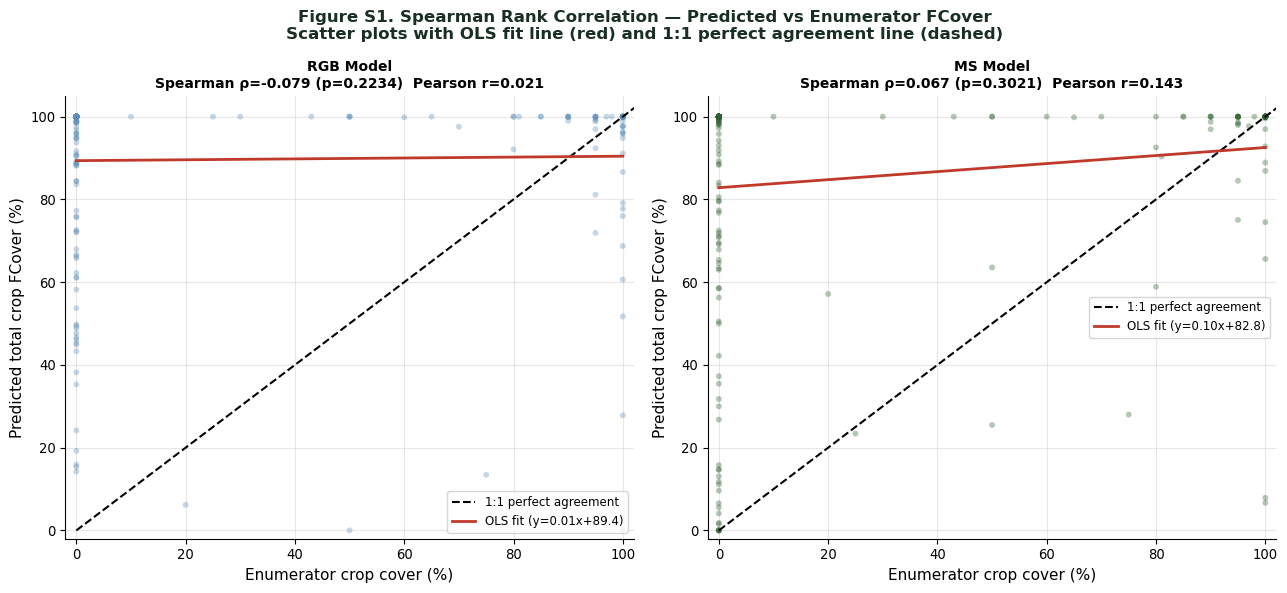

In [10]:
# ══════════════════════════════════════════════════════════════════
# TEST 2 — SPEARMAN RANK CORRELATION
# H₀: No monotonic relationship between predicted and enumerator FCover
# ══════════════════════════════════════════════════════════════════
print("="*65)
print("TEST 2: SPEARMAN RANK CORRELATION")
print("H₀: No monotonic association between predicted and enumerator FCover")
print("="*65)

results_spearman = []
for label, df in [("RGB", rgb), ("MS", ms)]:
    rho, p = spearmanr(df["pred_total_crop"], df["crop_cov_1"])
    r_pearson, p_pearson = pearsonr(df["pred_total_crop"], df["crop_cov_1"])
    reject = p < ALPHA

    print(f"\n  {label}")
    print(f"  Spearman ρ         : {rho:.4f}")
    print(f"  p-value            : {p:.6f}")
    print(f"  Pearson r          : {r_pearson:.4f}")
    print(f"  Decision           : {'REJECT H₀' if reject else 'FAIL TO REJECT H₀'}")
    print(f"  Interpretation     : There is "
          f"{'a statistically significant' if reject else 'no significant'} "
          f"monotonic association (ρ={rho:.3f}, p={p:.4f})")
    results_spearman.append({
        "Model":label,"Spearman ρ":round(rho,4),"p-value":round(p,6),
        "Pearson r":round(r_pearson,4),"Reject H0":reject})

spearman_df = pd.DataFrame(results_spearman)

# ── Figure: scatter + rank correlation ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 6), facecolor="white")
fig.suptitle(
    "Figure S1. Spearman Rank Correlation — Predicted vs Enumerator FCover\n"
    "Scatter plots with OLS fit line (red) and 1:1 perfect agreement line (dashed)",
    fontsize=12, fontweight="bold", color="#1A2F23")

for ax, (label, df, color) in zip(axes, [
    ("RGB", rgb, "#5B8DB8"), ("MS", ms, "#2C5F2D")
]):
    x = df["crop_cov_1"].values
    y = df["pred_total_crop"].values
    rho, p = spearmanr(y, x)
    r_p, _  = pearsonr(y, x)

    ax.scatter(x, y, alpha=0.35, s=18, color=color,
               edgecolors="none", zorder=3)

    # 1:1 line
    lims = [0, max(x.max(), y.max())*1.05]
    ax.plot(lims, lims, "k--", lw=1.5, label="1:1 perfect agreement", zorder=4)

    # OLS fit
    slope, intercept, *_ = stats.linregress(x, y)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, slope*xs+intercept, color="#C0392B", lw=2,
            label=f"OLS fit (y={slope:.2f}x+{intercept:.1f})", zorder=5)

    ax.set_xlabel("Enumerator crop cover (%)", fontsize=11)
    ax.set_ylabel("Predicted total crop FCover (%)", fontsize=11)
    ax.set_title(
        f"{label} Model\nSpearman ρ={rho:.3f} (p={p:.4f})  "
        f"Pearson r={r_p:.3f}",
        fontsize=10, fontweight="bold")
    ax.legend(fontsize=8.5)
    ax.set_xlim(-2, 102); ax.set_ylim(-2, 105)

plt.tight_layout()
plt.savefig(FIG_DIR/"fig_s1_spearman_scatter.png",
            dpi=150, bbox_inches="tight")
print("Saved -> fig_s1_spearman_scatter.png")
plt.show()

## Test 3. McNemar Test — RGB vs MS Classification Performance

Tests whether the MS model makes significantly fewer classification errors
than the RGB model on the same test-set pixels.

**H₀:** The RGB and MS models make the same number of correct
pixel-level classifications (discordant pairs b = c).

Only discordant pairs matter:
- b = RGB correct, MS wrong
- c = RGB wrong, MS correct

If c >> b → MS significantly better. If b ≈ c → no significant difference.

TEST 3: McNEMAR TEST — RGB vs MS Classification Performance
H₀: No significant difference in pixel-level classification
    accuracy between RGB and MS models (b = c)

  Contingency table (rows=RGB, cols=MS):
                        MS correct    MS wrong
  RGB correct           17,839,325   9,896,954
  RGB wrong             14,672,468   103,388,114
  Total pixels: 145,796,861

  RGB overall accuracy : 19.024%
  MS  overall accuracy : 22.299%

  Discordant pairs:
  b (RGB correct, MS wrong) : 9,896,954
  c (RGB wrong, MS correct) : 14,672,468
  Direction: MS > RGB (MS makes fewer errors)

  McNemar statistic (χ²) : 928207.6075
  p-value                : 0.00000000
  Decision               : REJECT H₀
  Interpretation         : The MS model makes significantly different errors from the RGB model (α=0.05)

  Odds ratio (c/b)       : 1.4825
  Meaning: MS model corrects 1.48x more discordant pixels
           than RGB model — i.e. where they disagree, MS is
           1.48x more likely to 

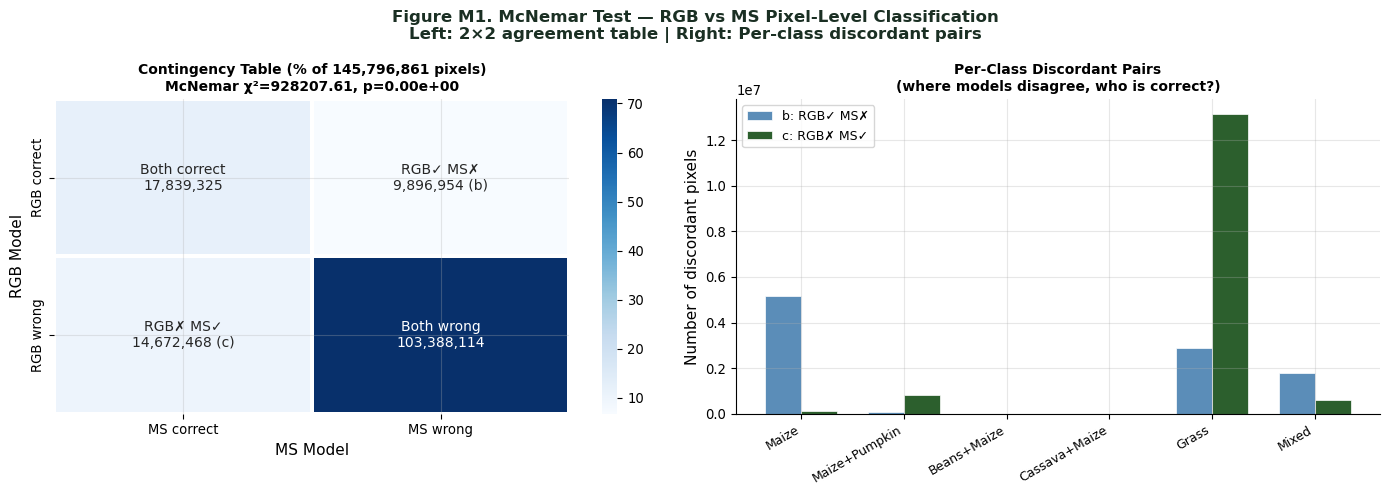

In [11]:
# ══════════════════════════════════════════════════════════════════
# TEST 3 — McNEMAR TEST
# RGB vs MS pixel-level classification performance
# H₀: The RGB and MS models make equal numbers of correct predictions
#     (discordant pairs b = c)
# ══════════════════════════════════════════════════════════════════
import rasterio
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

print("="*65)
print("TEST 3: McNEMAR TEST — RGB vs MS Classification Performance")
print("H₀: No significant difference in pixel-level classification")
print("    accuracy between RGB and MS models (b = c)")
print("="*65)

PRED_DIR  = BASE_DIR / "Predictions"
TEST_SAS  = ["10125706","10605304","10865805"]
IGNORE    = 255
CLASS_NAMES = ["Maize","Maize+Pumpkin","Beans+Maize",
               "Cassava+Maize","Grass","Mixed"]

# ── Collect pixel-level correct/incorrect for both models ─────────
rgb_correct = []
ms_correct  = []

for sa_id in TEST_SAS:
    lbl_path = BASE_DIR / "Labels"          / f"{sa_id}_labels.tif"
    rgb_path = PRED_DIR  / "rgb_v3"         / f"{sa_id}_pred_rgb.tif"
    ms_path  = PRED_DIR  / "ms_v1"          / f"{sa_id}_pred_ms.tif"

    with rasterio.open(lbl_path) as s: lbl = s.read(1).ravel()
    with rasterio.open(rgb_path) as s: rgb = s.read(1).ravel()
    with rasterio.open(ms_path)  as s: ms  = s.read(1).ravel()

    valid = lbl != IGNORE
    rgb_correct.append((rgb[valid] == lbl[valid]).astype(int))
    ms_correct.append( (ms[valid]  == lbl[valid]).astype(int))

rgb_c = np.concatenate(rgb_correct)
ms_c  = np.concatenate(ms_correct)

n_total = len(rgb_c)

# ── Build 2×2 contingency table ───────────────────────────────────
# Rows = RGB (correct=1 / wrong=0), Cols = MS (correct=1 / wrong=0)
a = int(((rgb_c==1) & (ms_c==1)).sum())  # both correct
b = int(((rgb_c==1) & (ms_c==0)).sum())  # RGB correct, MS wrong
c = int(((rgb_c==0) & (ms_c==1)).sum())  # RGB wrong, MS correct
d = int(((rgb_c==0) & (ms_c==0)).sum())  # both wrong

table = np.array([[a, b],[c, d]])

print(f"\n  Contingency table (rows=RGB, cols=MS):")
print(f"  {'':20s}  MS correct    MS wrong")
print(f"  {'RGB correct':20s}  {a:>10,}   {b:>9,}")
print(f"  {'RGB wrong':20s}  {c:>10,}   {d:>9,}")
print(f"  Total pixels: {n_total:,}")
print(f"\n  RGB overall accuracy : {(a+b)/n_total*100:.3f}%")
print(f"  MS  overall accuracy : {(a+c)/n_total*100:.3f}%")
print(f"\n  Discordant pairs:")
print(f"  b (RGB correct, MS wrong) : {b:,}")
print(f"  c (RGB wrong, MS correct) : {c:,}")
print(f"  Direction: {'MS > RGB' if c > b else 'RGB > MS'} "
      f"({'MS makes fewer errors' if c>b else 'RGB makes fewer errors'})")

# ── McNemar test ──────────────────────────────────────────────────
result = mcnemar(table, exact=False, correction=True)
reject = result.pvalue < ALPHA

print(f"\n  McNemar statistic (χ²) : {result.statistic:.4f}")
print(f"  p-value                : {result.pvalue:.8f}")
print(f"  Decision               : {'REJECT H₀' if reject else 'FAIL TO REJECT H₀'}")
print(f"  Interpretation         : The MS model makes "
      f"{'significantly' if reject else 'no significantly'} "
      f"different errors from the RGB model (α={ALPHA})")

# ── Effect size: odds ratio of discordant pairs ───────────────────
odds_ratio = c / b if b > 0 else float("inf")
print(f"\n  Odds ratio (c/b)       : {odds_ratio:.4f}")
print(f"  Meaning: MS model corrects {odds_ratio:.2f}x more discordant pixels")
print(f"           than RGB model — i.e. where they disagree, MS is")
print(f"           {odds_ratio:.2f}x more likely to be correct")

# ── Per-class breakdown of disagreements ─────────────────────────
print(f"\n  Per-class breakdown of discordant pixels:")
print(f"  {'Class':20s}  {'b (RGB✓ MS✗)':>14}  {'c (RGB✗ MS✓)':>14}  "
      f"{'Net MS advantage':>16}")

all_lbl = np.concatenate([
    rasterio.open(BASE_DIR/"Labels"/f"{s}_labels.tif").read(1).ravel()
    for s in TEST_SAS])
all_rgb = np.concatenate([
    rasterio.open(PRED_DIR/"rgb_v3"/f"{s}_pred_rgb.tif").read(1).ravel()
    for s in TEST_SAS])
all_ms  = np.concatenate([
    rasterio.open(PRED_DIR/"ms_v1"/f"{s}_pred_ms.tif").read(1).ravel()
    for s in TEST_SAS])

valid_mask = all_lbl != IGNORE
lbl_v = all_lbl[valid_mask]
rgb_v = all_rgb[valid_mask]
ms_v  = all_ms[valid_mask]

class_rows = []
for i, name in enumerate(CLASS_NAMES):
    cls_mask = lbl_v == i
    b_cls = int(((rgb_v[cls_mask]==i) & (ms_v[cls_mask]!=i)).sum())
    c_cls = int(((rgb_v[cls_mask]!=i) & (ms_v[cls_mask]==i)).sum())
    net   = c_cls - b_cls
    print(f"  {name:20s}  {b_cls:>14,}  {c_cls:>14,}  "
          f"{net:>+16,}  ({'MS better' if net>0 else 'RGB better' if net<0 else 'equal'})")
    class_rows.append({"Class":name,"b":b_cls,"c":c_cls,"Net":net})

class_df = pd.DataFrame(class_rows)

# ── Figure 1: Contingency heatmap ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="white")
fig.suptitle(
    "Figure M1. McNemar Test — RGB vs MS Pixel-Level Classification\n"
    "Left: 2×2 agreement table | Right: Per-class discordant pairs",
    fontsize=12, fontweight="bold", color="#1A2F23")

# Left: 2x2 heatmap
labels_2x2 = np.array([
    [f"Both correct\n{a:,}", f"RGB✓ MS✗\n{b:,} (b)"],
    [f"RGB✗ MS✓\n{c:,} (c)", f"Both wrong\n{d:,}"]
])
ct_pct = table / n_total * 100
sns.heatmap(ct_pct, ax=axes[0],
            annot=labels_2x2, fmt="",
            cmap="Blues", cbar=True,
            xticklabels=["MS correct","MS wrong"],
            yticklabels=["RGB correct","RGB wrong"],
            linewidths=1.5, linecolor="white",
            annot_kws={"size":10})
axes[0].set_title(
    f"Contingency Table (% of {n_total:,} pixels)\n"
    f"McNemar χ²={result.statistic:.2f}, p={result.pvalue:.2e}",
    fontsize=10, fontweight="bold")
axes[0].set_ylabel("RGB Model", fontsize=11)
axes[0].set_xlabel("MS Model", fontsize=11)

# Right: per-class bar chart of discordant pairs
x = np.arange(len(CLASS_NAMES))
w = 0.35
axes[1].bar(x-w/2, class_df["b"], w, label="b: RGB✓ MS✗",
            color="#5B8DB8", edgecolor="white", linewidth=0.5)
axes[1].bar(x+w/2, class_df["c"], w, label="c: RGB✗ MS✓",
            color="#2C5F2D", edgecolor="white", linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(CLASS_NAMES, rotation=30, ha="right", fontsize=9)
axes[1].set_ylabel("Number of discordant pixels", fontsize=11)
axes[1].set_title("Per-Class Discordant Pairs\n"
                   "(where models disagree, who is correct?)",
                   fontsize=10, fontweight="bold")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR/"fig_m1_mcnemar_rgb_vs_ms.png",
            dpi=150, bbox_inches="tight")
print(f"\nSaved -> fig_m1_mcnemar_rgb_vs_ms.png")
plt.show()

# Store for summary table
mcnemar_result = {
    "statistic": result.statistic,
    "pvalue":    result.pvalue,
    "b": b, "c": c,
    "odds_ratio": odds_ratio,
    "reject": reject
}

## Test 4. Kruskal-Wallis + Dunn Post-hoc

Non-parametric equivalent of one-way ANOVA. Tests whether cultivation intensity differs significantly across the five farming system types.

TEST 4: KRUSKAL-WALLIS TEST
H₀: Cultivation intensity is equal across farming systems

  Groups and sample sizes:
  Diversified multi-crop system           : n= 3  median=92.9%
  Maize monoculture dominant              : n=11  median=89.0%
  Maize-pumpkin intercrop system          : n= 2  median=74.7%
  Mixed / transitional                    : n= 2  median=36.0%
  Mixed cereal-legume system              : n= 1  median=92.2%
Kruskal-Wallis H  : 7.2852
  p-value           : 0.121564
  Decision          : FAIL TO REJECT H₀
Saved -> fig_k1_kruskal_wallis.png


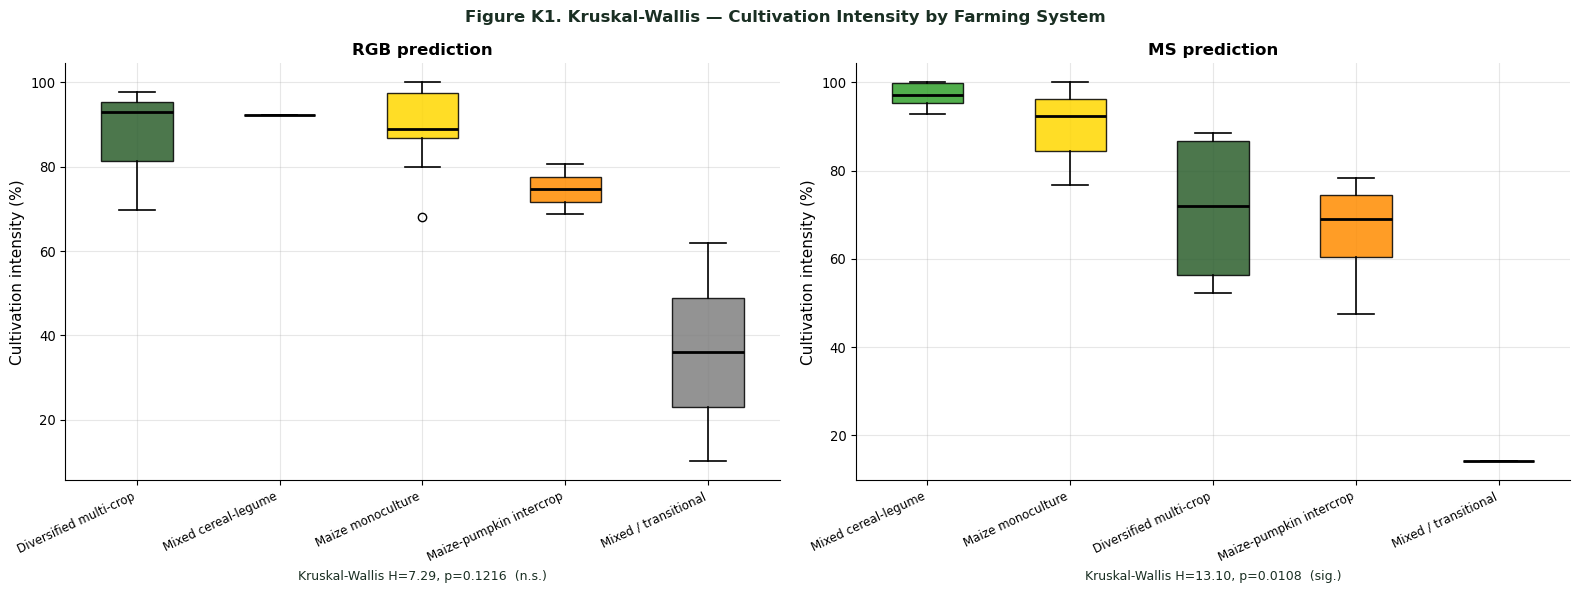

In [12]:
# ══════════════════════════════════════════════════════════════════
# TEST 4 — KRUSKAL-WALLIS + DUNN POST-HOC
# H₀: Cultivation intensity does not differ across farming systems
# ══════════════════════════════════════════════════════════════════
print("="*65)
print("TEST 4: KRUSKAL-WALLIS TEST")
print("H₀: Cultivation intensity is equal across farming systems")
print("="*65)

# Merge cultivation intensity with farming system per SA
ci_df = area_df[area_df["source"]=="rgb_pred"][
    ["SA","crop_intensity_pct"]].copy()
fs_df = farming_df[farming_df["source"]=="rgb_pred"][
    ["SA","farming_system"]].copy()
kw_df = ci_df.merge(fs_df, on="SA")

groups = {fs: grp["crop_intensity_pct"].values
          for fs, grp in kw_df.groupby("farming_system")}

print("\n  Groups and sample sizes:")
for fs, vals in groups.items():
    print(f"  {fs:40s}: n={len(vals):2d}  "
          f"median={np.median(vals):.1f}%")

stat, p = kruskal(*groups.values())
reject  = p < ALPHA

print(f"Kruskal-Wallis H  : {stat:.4f}")
print(f"  p-value           : {p:.6f}")
print(f"  Decision          : {'REJECT H₀' if reject else 'FAIL TO REJECT H₀'}")

if reject:
    print("\n  Post-hoc Dunn test (Bonferroni correction):")
    try:
        dunn_result = posthoc_dunn(
            kw_df, val_col="crop_intensity_pct",
            group_col="farming_system", p_adjust="bonferroni")
        print(dunn_result.round(4).to_string())
    except Exception as e:
        print(f"  Dunn test error: {e}")
        print("  Install: pip install scikit-posthocs")

# ── Figure: boxplot by farming system ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor="white")
fig.suptitle(
    "Figure K1. Kruskal-Wallis — Cultivation Intensity by Farming System",
    fontsize=12, fontweight="bold", color="#1A2F23")

fs_colors = {
    "Maize monoculture dominant":    "#FFD700",
    "Mixed cereal-legume system":    "#33A02C",
    "Diversified multi-crop system": "#2C5F2D",
    "Maize-pumpkin intercrop system":"#FF8C00",
    "Mixed / transitional":          "#808080",
}

for ax, src in zip(axes, ["rgb_pred","ms_pred"]):
    ci  = area_df[area_df["source"]==src][["SA","crop_intensity_pct"]]
    fs  = farming_df[farming_df["source"]==src][["SA","farming_system"]]
    tmp = ci.merge(fs, on="SA")

    order = (tmp.groupby("farming_system")["crop_intensity_pct"]
               .median().sort_values(ascending=False).index.tolist())

    data_list = [tmp[tmp["farming_system"]==fs_name]["crop_intensity_pct"].values
                 for fs_name in order]
    colors    = [fs_colors.get(fs_name,"#888888") for fs_name in order]

    bp = ax.boxplot(data_list, patch_artist=True,
                    medianprops={"color":"black","lw":2},
                    whiskerprops={"lw":1.2},
                    capprops={"lw":1.2})
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color); patch.set_alpha(0.85)

    ax.set_xticks(range(1, len(order)+1))
    ax.set_xticklabels(
        [n.replace(" system","").replace(" dominant","")
         for n in order],
        rotation=25, ha="right", fontsize=8.5)
    ax.set_ylabel("Cultivation intensity (%)", fontsize=11)
    ax.set_title(f"{'RGB' if 'rgb' in src else 'MS'} prediction",
                  fontweight="bold")
    stat_k, p_k = kruskal(*[v for v in
        [tmp[tmp["farming_system"]==fs_n]["crop_intensity_pct"].values
         for fs_n in order] if len(v)>0])
    ax.set_xlabel(
        f"Kruskal-Wallis H={stat_k:.2f}, p={p_k:.4f}  "
        f"({'sig.' if p_k<0.05 else 'n.s.'})",
        fontsize=9, color="#1A2F23")

plt.tight_layout()
plt.savefig(FIG_DIR/"fig_k1_kruskal_wallis.png",
            dpi=150, bbox_inches="tight")
print("Saved -> fig_k1_kruskal_wallis.png")
plt.show()

## Test 5. OLS Regression

Characterises the systematic bias formally. Slope ≠ 1 and intercept ≠ 0 indicate systematic over- or under-prediction.

RGB rows: 238  MS rows: 238

  RGB
  Intercept : 89.3583  (95% CI: [86.10, 92.62], p=0.0000)
  Slope     : 0.0108  (95% CI: [-0.06, 0.08], p=0.7481)
  R²        : 0.0004

  MS
  Intercept : 82.8262  (95% CI: [78.57, 87.09], p=0.0000)
  Slope     : 0.0971  (95% CI: [0.01, 0.18], p=0.0274)
  R²        : 0.0205
Model  Intercept  Slope     R²  p (slope)  CI slope low  CI slope high
  RGB    89.3583 0.0108 0.0004   0.748140        -0.055          0.077
   MS    82.8262 0.0971 0.0205   0.027392         0.011          0.183

Saved -> fig_r1_regression.png


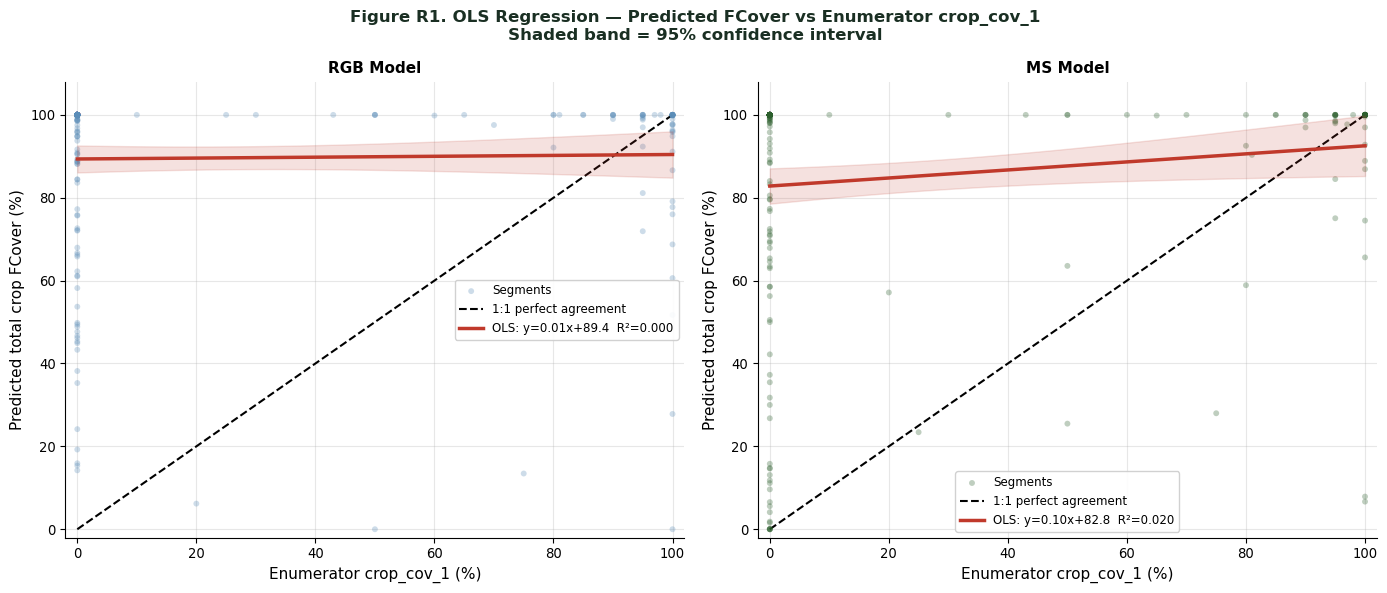

In [20]:
# ══════════════════════════════════════════════════════════════════
# TEST 5 — OLS REGRESSION (self-contained)
# ══════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

BASE_DIR  = Path(r"E:\THESIS_COLLINS HLORDZIE\02_PROCESSED")
STATS_DIR = BASE_DIR / "AgriStats"
FIG_DIR   = STATS_DIR / "Figures" / "InferentialStats"
ALPHA     = 0.05

# ── Reload fcover data fresh ──────────────────────────────────────
fcover_df = pd.read_csv(BASE_DIR / "segment_fcover_results.csv")
fcover_df["newgid"] = fcover_df["newgid"].astype(str).str.strip()

crop_cols = [c for c in fcover_df.columns
             if c.startswith("pred_fcover_") and "Grass" not in c]
fcover_df["pred_total_crop"] = fcover_df[crop_cols].sum(axis=1)
fcover_df["crop_cov_1"]  = pd.to_numeric(fcover_df["crop_cov_1"],  errors="coerce")
fcover_df["pred_total_crop"] = pd.to_numeric(fcover_df["pred_total_crop"], errors="coerce")
fcover_df = fcover_df.dropna(subset=["crop_cov_1","pred_total_crop"])

rgb = fcover_df[fcover_df["modality"].str.contains("rgb")].copy().reset_index(drop=True)
ms  = fcover_df[fcover_df["modality"].str.contains("ms") &
                ~fcover_df["modality"].str.contains("unmask")].copy().reset_index(drop=True)

print(f"RGB rows: {len(rgb)}  MS rows: {len(ms)}")

# ── Run regression ────────────────────────────────────────────────
results_reg = []
for label, df in [("RGB", rgb), ("MS", ms)]:
    x = df["crop_cov_1"].values.astype(float)
    y = df["pred_total_crop"].values.astype(float)

    X     = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    slope     = model.params[1]
    intercept = model.params[0]
    r2        = model.rsquared
    p_slope   = model.pvalues[1]
    p_int     = model.pvalues[0]
    ci        = model.conf_int()      # numpy array, not DataFrame
    ci_int    = ci[0]                 # intercept: [lower, upper]
    ci_slope  = ci[1]                 # slope:     [lower, upper]

    print(f"\n  {label}")
    print(f"  Intercept : {intercept:.4f}  "
          f"(95% CI: [{ci_int[0]:.2f}, {ci_int[1]:.2f}], p={p_int:.4f})")
    print(f"  Slope     : {slope:.4f}  "
          f"(95% CI: [{ci_slope[0]:.2f}, {ci_slope[1]:.2f}], p={p_slope:.4f})")
    print(f"  R²        : {r2:.4f}")
    results_reg.append({
        "Model":        label,
        "Intercept":    round(intercept, 4),
        "Slope":        round(slope,     4),
        "R²":           round(r2,        4),
        "p (slope)":    round(p_slope,   6),
        "CI slope low": round(ci_slope[0], 3),
        "CI slope high":round(ci_slope[1], 3)})

reg_df = pd.DataFrame(results_reg)
print(reg_df.to_string(index=False))

# ── Figure ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor="white")
fig.suptitle(
    "Figure R1. OLS Regression — Predicted FCover vs Enumerator crop_cov_1\n"
    "Shaded band = 95% confidence interval",
    fontsize=12, fontweight="bold", color="#1A2F23")

for ax, (label, df, color) in zip(axes, [
    ("RGB", rgb, "#5B8DB8"), ("MS", ms, "#2C5F2D")
]):
    x = df["crop_cov_1"].values.astype(float)
    y = df["pred_total_crop"].values.astype(float)
    X     = sm.add_constant(x)
    model = sm.OLS(y, X).fit()

    ax.scatter(x, y, alpha=0.3, s=18, color=color,
               edgecolors="none", zorder=3, label="Segments")
    ax.plot([0,100],[0,100],"k--",lw=1.5,label="1:1 perfect agreement")

    x_pred = np.linspace(0, 100, 200)
    X_pred = sm.add_constant(x_pred)
    pred   = model.get_prediction(X_pred)
    ci     = pred.conf_int(alpha=0.05)
    y_hat  = model.params[0] + model.params[1]*x_pred

    ax.plot(x_pred, y_hat, color="#C0392B", lw=2.5,
            label=f"OLS: y={model.params[1]:.2f}x+{model.params[0]:.1f}"
                  f"  R²={model.rsquared:.3f}", zorder=5)
    ax.fill_between(x_pred, ci[:,0], ci[:,1],
                    color="#C0392B", alpha=0.15, zorder=4)

    ax.set_xlabel("Enumerator crop_cov_1 (%)", fontsize=11)
    ax.set_ylabel("Predicted total crop FCover (%)", fontsize=11)
    ax.set_title(f"{label} Model", fontsize=11, fontweight="bold")
    ax.set_xlim(-2, 102); ax.set_ylim(-2, 108)
    ax.legend(fontsize=8.5, framealpha=0.9)

plt.tight_layout()
plt.savefig(FIG_DIR/"fig_r1_regression.png", dpi=150, bbox_inches="tight")
print("\nSaved -> fig_r1_regression.png")
plt.show()